In [12]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

from sklearn.model_selection import train_test_split

from sklearn.metrics import r2_score, mean_squared_error

from sklearn.preprocessing import StandardScaler

 



In [13]:
# 1. Load

df = pd.read_csv('Housing.csv')

print('Shape:', df.shape)

print(df.isnull().sum())

 



Shape: (545, 13)
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [14]:
# 2. Clean

df = df.dropna()                    # or fillna()

# encode categoricals if needed

# df['col'] = df['col'].map({...})

 



In [15]:
# 3. Define features and target

feature_cols = ['area', 'bedrooms', 'bathrooms']  # replace with real names

target_col   = 'price'                 # replace with real name

 

X = df[feature_cols]

y = df[target_col]

 



In [16]:
# 4. Split

X_train, X_test, y_train, y_test = train_test_split(

    X, y, test_size=0.2, random_state=42

)

print(f'Train: {len(X_train)}  Test: {len(X_test)}')

 


Train: 436  Test: 109


In [17]:
# 5. (Optional) Scale

scaler  = StandardScaler()

X_train = scaler.fit_transform(X_train)   # fit on train only!

X_test  = scaler.transform(X_test)        # transform test with same scaler

 



In [18]:
# 6. Train

model = LinearRegression()

model.fit(X_train, y_train)

 



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
# 7. Predict

y_pred = model.predict(X_test)

 



In [20]:
# 8. Evaluate

mse  = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2   = r2_score(y_test, y_pred)

print(f'RMSE: {rmse:.2f}')

print(f'R2:   {r2:.4f}')

 



RMSE: 1658324.60
R2:   0.4559


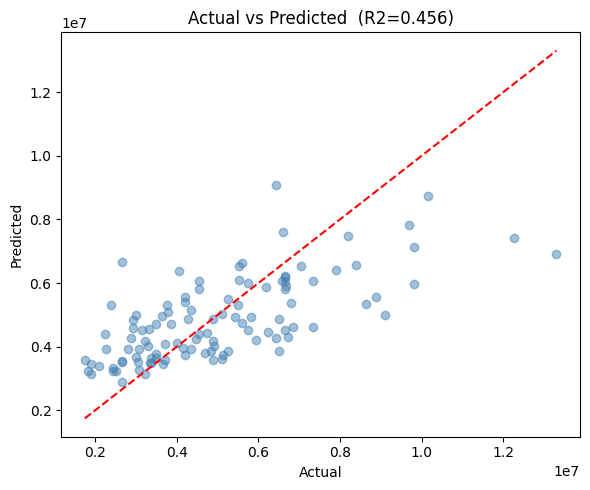

In [21]:


# 9. Visualise

plt.figure(figsize=(6,5))

plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue')

plt.plot([y_test.min(), y_test.max()],

         [y_test.min(), y_test.max()], 'r--')

plt.xlabel('Actual')

plt.ylabel('Predicted')

plt.title(f'Actual vs Predicted  (R2={r2:.3f})')

plt.tight_layout()

plt.savefig('results.png', dpi=150, bbox_inches='tight')

plt.show()

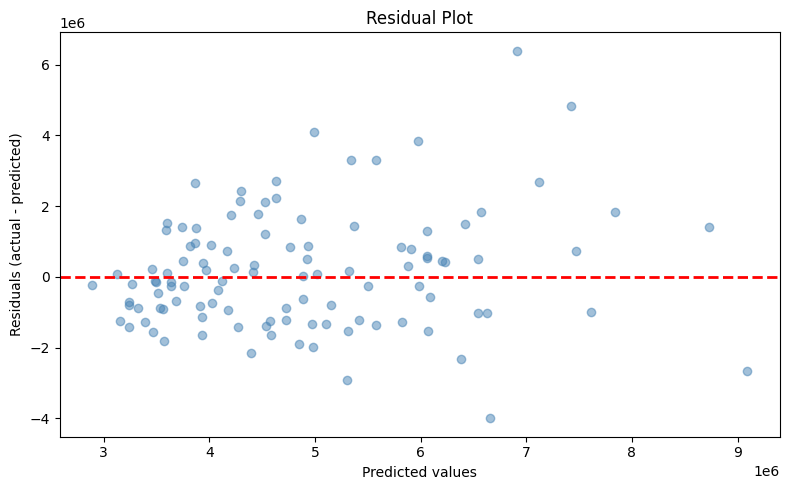

Mean of residuals:  152130.4309
Std of residuals:   1651331.83


In [22]:
# Residual plot

residuals = y_test.values - y_pred   # actual minus predicted

 

plt.figure(figsize=(8, 5))

plt.scatter(y_pred, residuals, alpha=0.5, color='steelblue')

plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

plt.title('Residual Plot')

plt.xlabel('Predicted values')

plt.ylabel('Residuals (actual - predicted)')

plt.tight_layout()

plt.savefig('residuals.png', dpi=150, bbox_inches='tight')

plt.show()

 

print(f'Mean of residuals:  {residuals.mean():.4f}')   # should be near 0

print(f'Std of residuals:   {residuals.std():.2f}')